# Train AdSpectra Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [2]:
df = pd.read_csv("advertising_budget_sales.csv")
df.drop("ID", axis=1, inplace=True)
df.head()

,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
df.isnull().sum()

TV Ad Budget           0
Radio Ad Budget        0
Newspaper Ad Budget    0
Sales                  0
dtype: int64

In [4]:
df.describe()

,TV Ad Budget,Radio Ad Budget,Newspaper Ad Budget,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [5]:
# Features & Target
X = df.drop(columns=["Sales"])
y = df["Sales"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
print(f" Shape of Training Data: {X_train.shape}")
print(f" Shape of Test Data: {X_test.shape}")

 Shape of Training Data: (160, 3)
 Shape of Test Data: (40, 3)


## Finding the best Regressor Model for this Dataset

In [8]:
# my short-listed ML models, can be more.
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "SVR": SVR() # Support Vector Regression
}

results = {} # Will be used to store the result(mean,std,RMSE) of the models. 

In [9]:
# Cross-validation & Evaluation
for name, model in models.items():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("regressor", model)
    ])
    # 5-fold cross-validation
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    rmse_scores = np.sqrt(
        -cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
    )
    results[name] = {
        "R2_mean": np.mean(scores),
        "R2_std": np.std(scores),
        "RMSE_mean": np.mean(rmse_scores)
    }

In [10]:
# Pick best model (highest R²)
best_model_name = max(results, key=lambda x: results[x]["R2_mean"])
best_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", models[best_model_name])
])

In [11]:
best_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


## Evaluating our Model based on the Test datasets

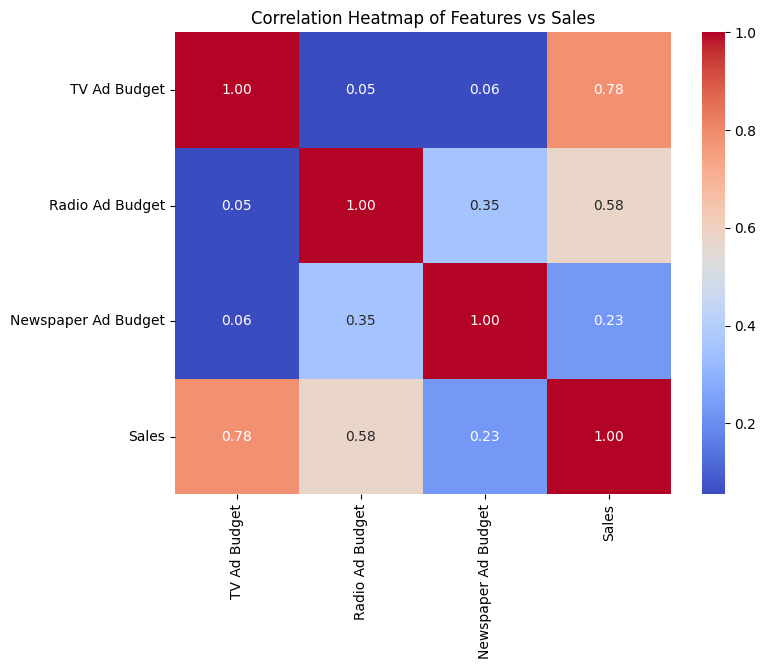

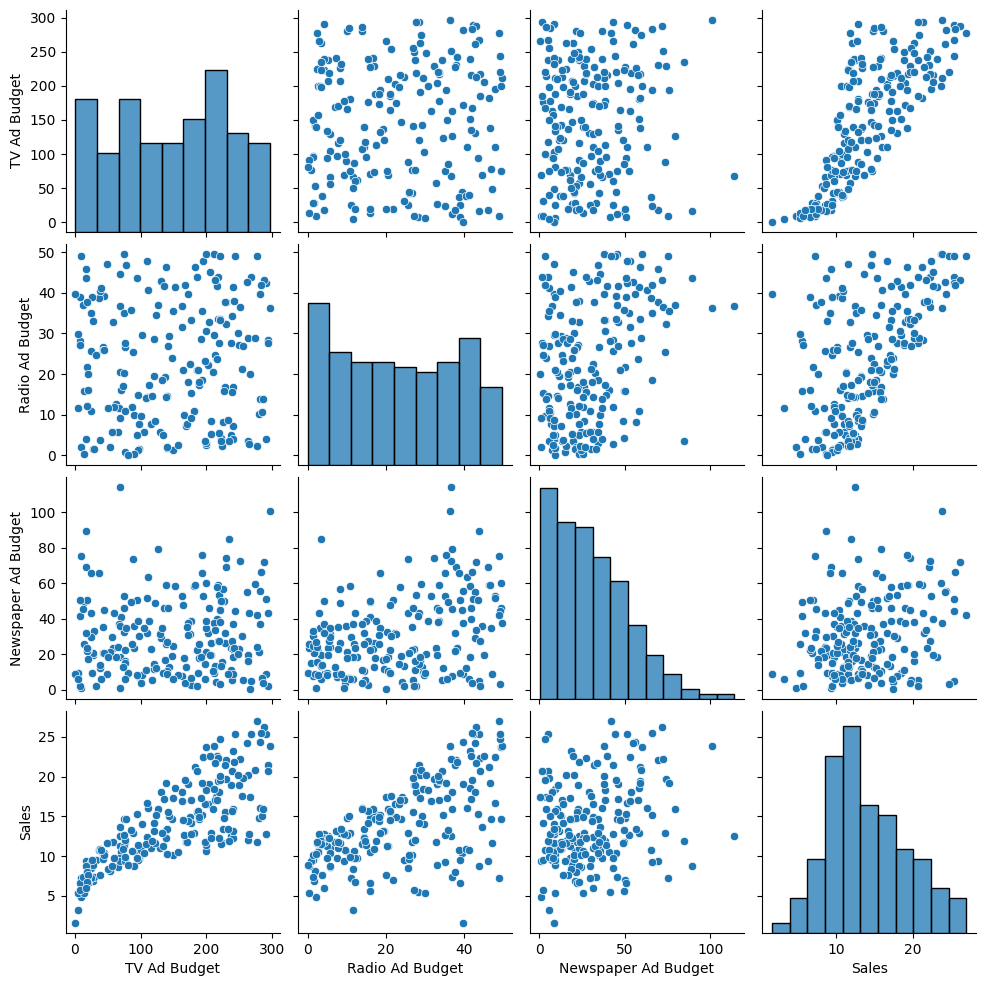

In [12]:
# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Features vs Sales")
plt.show()

# Pairplot
sns.pairplot(df, diag_kind="hist")
plt.show()

In [13]:
y_pred = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred)
print(f"Accuracy of model: {(test_r2 *100):.2f}%")
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

Accuracy of model: 98.13%


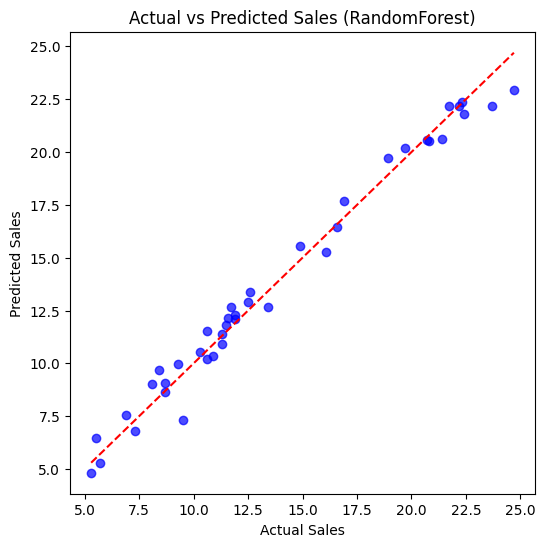

In [14]:
# Actual vs Predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales ({best_model_name})")
plt.show()

## Save the model

In [15]:
joblib.dump(best_model, "trained_model.pkl")
print("Model saved successfully!!")

Model saved successfully!!
